In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import FinanceDataReader as fdr

In [10]:
yf.Lookup("VIX").stock

VIX = yf.download("^VIX", start="2000-01-01", interval="1mo", ignore_tz=True)
NVDA = yf.download("NVDA", start="2000-01-01", interval="1mo", ignore_tz=True)
SNP = yf.download("^GSPC", start="2000-01-01", interval="1mo", ignore_tz=True)



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [20]:
# Min-Max 정규화를 위한 자동화 함수
def normalize(df: pd.DataFrame):
  return (df - df.min()) / (df.max() - df.min())

def standardize(df: pd.DataFrame):
  return (df - df.mean()) / df.std()

mo_index = VIX.index.tolist()

In [54]:
NVDA

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2000-01-01,0.070789,0.092156,0.066849,0.090246,4941456000
2000-02-01,0.122238,0.130356,0.068281,0.070908,9160848000
2000-03-01,0.161362,0.286495,0.109823,0.122238,17552160000
2000-04-01,0.170226,0.210813,0.108868,0.159900,6481728000
2000-05-01,0.217975,0.225257,0.144203,0.176672,8695584000
...,...,...,...,...,...
2026-01-01,191.119659,194.479478,177.600387,189.829721,3292228600
2026-02-01,177.180420,197.619317,171.020749,187.189873,3745445000


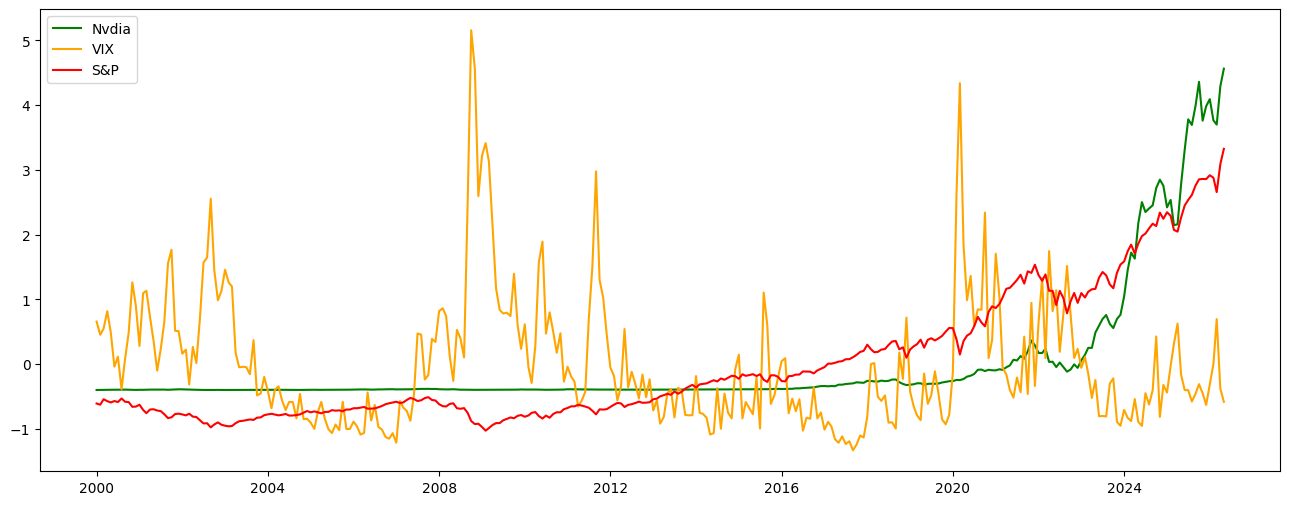

In [22]:
plt.figure(figsize=(16, 6))

# func = normalize
func = standardize

plt.plot(mo_index, func(NVDA["Close"]), label="Nvdia", color="green")
plt.plot(mo_index, func(VIX["Close"]), label="VIX", color="orange")
plt.plot(mo_index, func(SNP["Close"]), label="S&P", color="red")

plt.legend()
plt.show()

In [29]:
his_df = pd.concat([NVDA["Close"].diff(), VIX["Close"].diff(), SNP["Close"].diff()], axis=1)
his_df.corr()

Ticker,NVDA,^VIX,^GSPC
Ticker,,,
NVDA,1.000000,-0.129720,0.511626
^VIX,-0.129720,1.000000,-0.644997
^GSPC,0.511626,-0.644997,1.000000


In [55]:

print(NVDA)
print(len(NVDA.index))
print(min(NVDA.index))
print(max(NVDA.index))

Price            Close        High         Low        Open       Volume
Ticker            NVDA        NVDA        NVDA        NVDA         NVDA
Date                                                                   
2000-01-01    0.070789    0.092156    0.066849    0.090246   4941456000
2000-02-01    0.122238    0.130356    0.068281    0.070908   9160848000
2000-03-01    0.161362    0.286495    0.109823    0.122238  17552160000
2000-04-01    0.170226    0.210813    0.108868    0.159900   6481728000
2000-05-01    0.217975    0.225257    0.144203    0.176672   8695584000
...                ...         ...         ...         ...          ...
2026-01-01  191.119659  194.479478  177.600387  189.829721   3292228600
2026-02-01  177.180420  197.619317  171.020749  187.189873   3745445000
2026-03-01  174.390549  188.869775  164.261108  175.000516   4027150800
2026-04-01  199.570007  216.830002  171.369995  176.000000   3129548700
2026-05-01  211.139999  236.539993  194.740005  201.279999   355

In [ ]:
# NVDA["Close"].diff().std()
# NVDA["Close"].diff().mean()

# 4년 단위로 나눠서 보기
# 한번에 다보면 인플레이션 영향이 너무 크니까.
SLICE_YEAR = 4
SLICE_COUNT = len(NVDA.index)//(12*SLICE_YEAR) + 1

DF: pd.DataFrame = NVDA

print(SLICE_COUNT-1)

for i in range(SLICE_COUNT):
  start = i * 12 * SLICE_YEAR + 1
  end = None if (i+1)*(12*SLICE_YEAR) > len(DF) else ((i+1)*12*SLICE_YEAR) + 1
  print(start)
  print(end)
  tmp = DF["Close"].iloc[start: end]
  print(tmp.iloc[0])
  print(tmp.iloc[len(tmp)-1]) 

  print(f"\n --- \n")


# NVDA["Close"].diff().iloc()[0:12*5]

6
1
49
Ticker
NVDA    0.122238
Name: 2000-02-01 00:00:00, dtype: float64
Ticker
NVDA    0.169988
Name: 2004-01-01 00:00:00, dtype: float64

 --- 

49
97
Ticker
NVDA    0.169988
Name: 2004-02-01 00:00:00, dtype: float64
Ticker
NVDA    0.563593
Name: 2008-01-01 00:00:00, dtype: float64

 --- 

97
145
Ticker
NVDA    0.490251
Name: 2008-02-01 00:00:00, dtype: float64
Ticker
NVDA    0.338523
Name: 2012-01-01 00:00:00, dtype: float64

 --- 

145
193
Ticker
NVDA    0.347232
Name: 2012-02-01 00:00:00, dtype: float64
Ticker
NVDA    0.71442
Name: 2016-01-01 00:00:00, dtype: float64

 --- 

193
241
Ticker
NVDA    0.76491
Name: 2016-02-01 00:00:00, dtype: float64
Ticker
NVDA    5.884145
Name: 2020-01-01 00:00:00, dtype: float64

 --- 

241
289
Ticker
NVDA    6.721362
Name: 2020-02-01 00:00:00, dtype: float64
Ticker
NVDA    61.489414
Name: 2024-01-01 00:00:00, dtype: float64

 --- 

289
None
Ticker
NVDA    79.063683
Name: 2024-02-01 00:00:00, dtype: float64
Ticker
NVDA    211.139999
Name: 2026-05-0